# Smart Waste Detection and Segmentation

# Load Library

In [1]:
import numpy as np
import cv2 as cv
import pandas as pd
from skimage import measure
import matplotlib.pyplot as plt
import os
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Hitung Distribusi kelas

Distribusi kelas:
  cardboard: 403 gambar
  glass: 501 gambar
  metal: 410 gambar
  paper: 594 gambar
  plastic: 482 gambar
  trash: 137 gambar


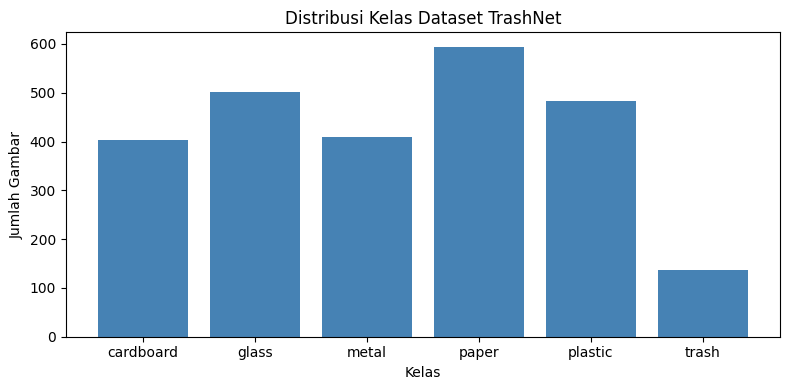

In [2]:
dataset_dir = 'dataset-resized'

class_count = Counter()
for class_name in os.listdir(dataset_dir):
    full_path = os.path.join(dataset_dir, class_name)
    if not os.path.isdir(full_path):
        continue
    count = len(os.listdir(full_path))
    class_count[class_name] = count

print("Distribusi kelas:")
for k, v in class_count.items():
    print(f"  {k}: {v} gambar")

plt.figure(figsize=(8, 4))
plt.bar(class_count.keys(), class_count.values(), color='steelblue')
plt.title("Distribusi Kelas Dataset TrashNet")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Gambar")
plt.tight_layout()
plt.show()

# Preprocessing and Augmentation Data

resize and normalisation

In [ ]:

class_names = sorted([
    d for d in os.listdir(dataset_dir)
    if os.path.isdir(os.path.join(dataset_dir, d))
])
print("Kelas ditemukan:", class_names)


images = []
labels = []

for label_idx, class_name in enumerate(class_names):
    class_dir = os.path.join(dataset_dir, class_name)
    for img_file in os.listdir(class_dir):
        if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
            images.append(os.path.join(class_dir, img_file))
            labels.append(label_idx)

print(f"Total gambar terkumpul: {len(images)}")
print(f"Total label: {len(labels)}")

Kelas ditemukan: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Total gambar terkumpul: 2527
Total label: 2527


training

In [4]:
# Split 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    images, labels, test_size=0.3, stratify=labels, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print(f"Train : {len(X_train)} gambar")
print(f"Val   : {len(X_val)} gambar")
print(f"Test  : {len(X_test)} gambar")

Train : 1768 gambar
Val   : 379 gambar
Test  : 380 gambar


Preprocessing and Augmentation

In [5]:
# Transform untuk TRAINING (dengan augmentasi)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Transform untuk VALIDASI & TEST (tanpa augmentasi, cukup resize + normalize)
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("Transform berhasil didefinisikan.")

Transform berhasil didefinisikan.


# Make and Custom Dataset

In [ ]:
class TrashDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

train_dataset = TrashDataset(X_train, y_train, transform=train_transform)
val_dataset   = TrashDataset(X_val,   y_val,   transform=val_transform)
test_dataset  = TrashDataset(X_test,  y_test,  transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

print(f"Train loader: {len(train_loader)} batch")
print(f"Val loader  : {len(val_loader)} batch")
print(f"Test loader : {len(test_loader)} batch")

Train loader: 56 batch
Val loader  : 12 batch
Test loader : 12 batch


# Build Model (ResNest50 Transfer Learning )

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = models.resnet18(weights= 'IMAGENET1K_V1' )

for param in model.parameters():
    param.requires_grad = False

num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_features, 6),
)

model =  model.to(device)
print("Model siap")
print(f'Jumlah kelas output: {len(class_names)}, {class_names}')

Using device: cpu
Model siap
Jumlah kelas output: 6, ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


# Training Loop

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

num_epochs = 10
best_val_acc = 0

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(num_epochs):
    # ---- Training Phase ----
    model.train()
    running_loss, correct, total = 0, 0, 0

    for images_batch, labels_batch in train_loader:
        images_batch = images_batch.to(device)
        labels_batch = labels_batch.to(device)

        optimizer.zero_grad()
        outputs = model(images_batch)
        loss = criterion(outputs, labels_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels_batch.size(0)
        correct += (predicted == labels_batch).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc  = correct / total


    model.eval()
    val_loss_sum, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images_batch, labels_batch in val_loader:
            images_batch = images_batch.to(device)
            labels_batch = labels_batch.to(device)
            outputs = model(images_batch)
            loss = criterion(outputs, labels_batch)
            val_loss_sum += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total   += labels_batch.size(0)
            val_correct += (predicted == labels_batch).sum().item()

    val_loss = val_loss_sum / len(val_loader)
    val_acc  = val_correct / val_total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"  ✓ Model terbaik disimpan (val_acc={val_acc:.4f})")

Epoch [1/10] Train Loss: 1.6005 Acc: 0.3518 | Val Loss: 1.1484 Acc: 0.6121
  ✓ Model terbaik disimpan (val_acc=0.6121)
Epoch [2/10] Train Loss: 1.2288 Acc: 0.5345 | Val Loss: 1.0091 Acc: 0.6412
  ✓ Model terbaik disimpan (val_acc=0.6412)
Epoch [3/10] Train Loss: 1.0305 Acc: 0.6210 | Val Loss: 0.8990 Acc: 0.6913
  ✓ Model terbaik disimpan (val_acc=0.6913)
Epoch [4/10] Train Loss: 0.9656 Acc: 0.6538 | Val Loss: 0.8718 Acc: 0.6887
Epoch [5/10] Train Loss: 0.9359 Acc: 0.6340 | Val Loss: 0.8389 Acc: 0.7177
  ✓ Model terbaik disimpan (val_acc=0.7177)
Epoch [6/10] Train Loss: 0.8859 Acc: 0.6799 | Val Loss: 0.8742 Acc: 0.6807
Epoch [7/10] Train Loss: 0.8663 Acc: 0.6657 | Val Loss: 0.7793 Acc: 0.7256
  ✓ Model terbaik disimpan (val_acc=0.7256)
Epoch [8/10] Train Loss: 0.8820 Acc: 0.6606 | Val Loss: 0.7708 Acc: 0.7282
  ✓ Model terbaik disimpan (val_acc=0.7282)
Epoch [9/10] Train Loss: 0.8427 Acc: 0.6838 | Val Loss: 0.7937 Acc: 0.6887
Epoch [10/10] Train Loss: 0.8216 Acc: 0.7053 | Val Loss: 0.72

# Visualisasi Training

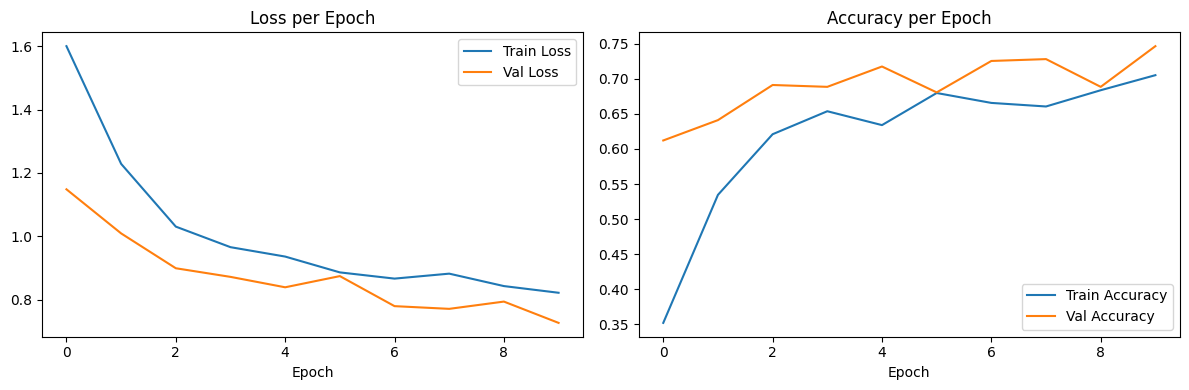

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses,   label='Val Loss')
ax1.set_title('Loss per Epoch')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(train_accs, label='Train Accuracy')
ax2.plot(val_accs,   label='Val Accuracy')
ax2.set_title('Accuracy per Epoch')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.show()